In [1]:
from Problems import P1
from NeuralES import NeuralES
import numpy as np
import matplotlib.pyplot as plt
from pymoo.visualization.scatter import Scatter
from pymoo.util.nds.non_dominated_sorting import find_non_dominated as find_nd

In [2]:
dim = 128
p = P1(dim)

In [3]:
nes = NeuralES(p)

In [4]:
n_eval = 1e6  # number of evaluations
hist, x, f, model = nes.evolve(n_eval)

0, 0.0%, IGD: CUR 0.4865 | OPT 0.4979, 0.00min
10, 0.4%, IGD: CUR 0.5009 | OPT 0.4777, 0.01min
20, 0.8%, IGD: CUR 0.3317 | OPT 0.3526, 0.02min
30, 1.1%, IGD: CUR 0.3065 | OPT 0.3035, 0.02min
40, 1.5%, IGD: CUR 0.2923 | OPT 0.2838, 0.03min
50, 1.8%, IGD: CUR 0.2176 | OPT 0.2380, 0.04min
60, 2.2%, IGD: CUR 0.1922 | OPT 0.1853, 0.05min
70, 2.6%, IGD: CUR 0.1744 | OPT 0.1789, 0.05min
80, 2.9%, IGD: CUR 0.1779 | OPT 0.1729, 0.06min
90, 3.3%, IGD: CUR 0.1819 | OPT 0.1764, 0.07min
100, 3.6%, IGD: CUR 0.1506 | OPT 0.1455, 0.07min
110, 4.0%, IGD: CUR 0.1449 | OPT 0.1386, 0.08min
120, 4.4%, IGD: CUR 0.1172 | OPT 0.1131, 0.09min
130, 4.7%, IGD: CUR 0.1289 | OPT 0.1127, 0.09min
140, 5.1%, IGD: CUR 0.1143 | OPT 0.0922, 0.10min
150, 5.4%, IGD: CUR 0.1546 | OPT 0.0922, 0.11min
160, 5.8%, IGD: CUR 0.1635 | OPT 0.0920, 0.11min
170, 6.2%, IGD: CUR 0.1466 | OPT 0.0917, 0.12min
180, 6.5%, IGD: CUR 0.1333 | OPT 0.0917, 0.13min
190, 6.9%, IGD: CUR 0.1343 | OPT 0.0912, 0.13min
200, 7.2%, IGD: CUR 0.1373 | OP

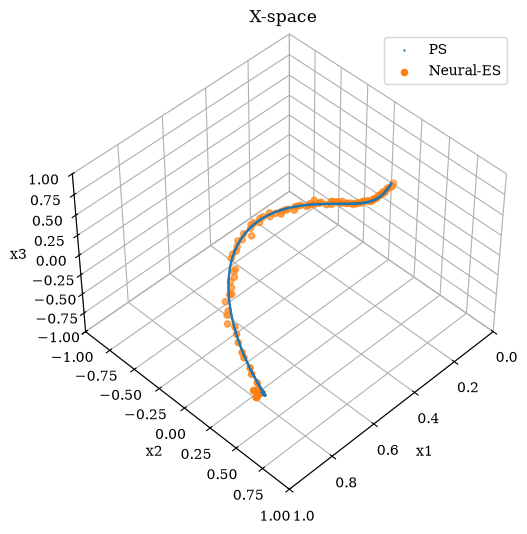

In [5]:
sc = Scatter(legend=True, title='X-space')
sc.add(p.ps(1000)[:, :3], color='tab:blue', marker='.', s=2, label='PS')
sc.add(x[:, :3], color='tab:orange', label='Neural-ES')
sc.do()
sc.apply(lambda ax: ax.set_xlim(p.xl[0], p.xu[0]))
sc.apply(lambda ax: ax.set_ylim(p.xl[1], p.xu[1]))
sc.apply(lambda ax: ax.set_zlim(p.xl[2], p.xu[2]))
sc.apply(lambda ax: ax.set_xlabel('x1'))
sc.apply(lambda ax: ax.set_ylabel('x2'))
sc.apply(lambda ax: ax.set_zlabel('x3'))
sc.show()

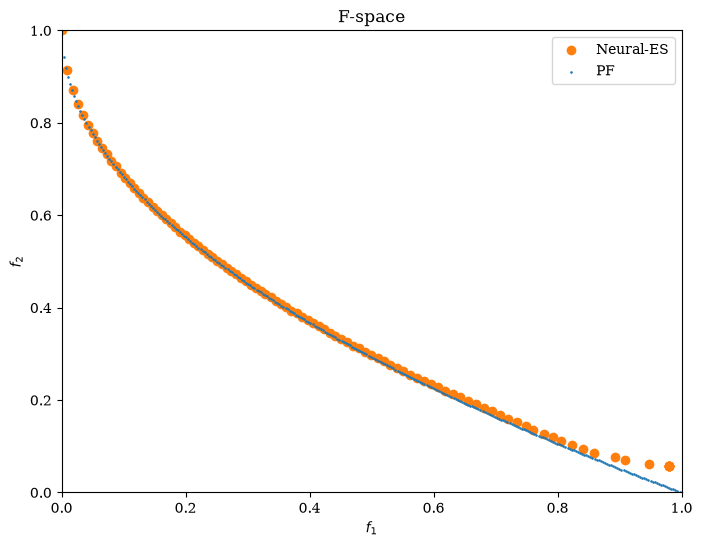

In [6]:
plot = Scatter(legend=True, title='F-space')  # , angle=(20,-60))
plot.add(f, color="tab:orange", label='Neural-ES')
plot.add(p.pareto_front(), marker='.', s=3, color="tab:blue", label='PF')
plot.do()
plot.apply(lambda ax: ax.set_xlim(p.zl[0], p.zu[0]))
plot.apply(lambda ax: ax.set_ylim(p.zl[1], p.zu[1]))
plot.show()

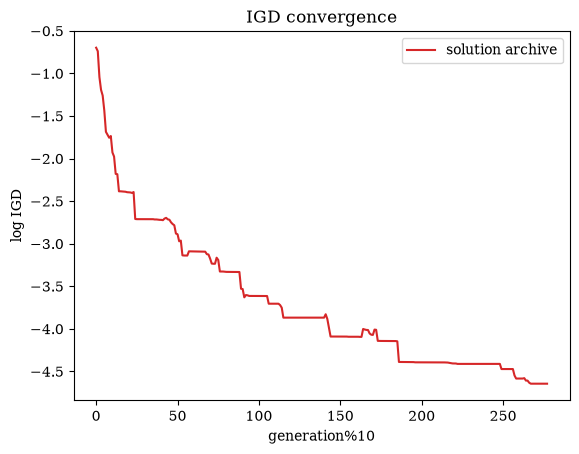

In [7]:
igd_bst = np.log(np.array(hist['igd0']))
plt.plot(igd_bst, label='solution archive', color='tab:red')
plt.xlabel("generation%10")
plt.ylabel('log IGD')
plt.title('IGD convergence')
plt.legend()
plt.show()